# Regressão Linear

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import tarfile
import urllib.request
from sklearn.model_selection import ShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sqlalchemy import Function

<br><br>

## Baixar e carregar o dataset

In [2]:

def load_housing_data():
    tarball_path = Path("dataset/housing.tgz")
    if not tarball_path.is_file():
        Path("dataset").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="dataset")
    return pd.read_csv(Path("dataset/housing/housing.csv"))

housing = load_housing_data()

<br><br>

## Visualização rápida dos dados

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [5]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [7]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

<br><br>

## Seleciona algumas colunas para um novo conjunto de dados

In [67]:
housing_cut = housing.drop(columns=['longitude', 'latitude', 'total_bedrooms', 'households', 'ocean_proximity'])

In [68]:
housing_cut

,housing_median_age,total_rooms,population,median_income,median_house_value
0,41.0,880.0,322.0,8.3252,452600.0
1,21.0,7099.0,2401.0,8.3014,358500.0
2,52.0,1467.0,496.0,7.2574,352100.0
3,52.0,1274.0,558.0,5.6431,341300.0
4,52.0,1627.0,565.0,3.8462,342200.0
...,...,...,...,...,...
20635,25.0,1665.0,845.0,1.5603,78100.0
20636,18.0,697.0,356.0,2.5568,77100.0
20637,17.0,2254.0,1007.0,1.7000,92300.0
20638,18.0,1860.0,741.0,1.8672,84700.0


<br><br>

## Divide o conjunto de dados em treino (80%) e teste (20%)

In [69]:
splitter = ShuffleSplit(n_splits=1, test_size=.20, random_state=0)
strat_splits = []
for train_index, test_index in splitter.split(housing_cut):
    train_set_n = housing_cut.iloc[train_index]
    test_set_n = housing_cut.iloc[test_index]
    strat_splits.append([train_set_n, test_set_n])


train_set = strat_splits[0][0]
test_set = strat_splits[0][1]

print('Total de exemplos')
print(f'Treino: {len(train_set)}')
print(f'Teste: {len(test_set)}')

Total de exemplos
Treino: 16512
Teste: 4128


In [70]:
X_train_set = train_set.drop(columns=['median_house_value'])
y_train_set = train_set['median_house_value'].copy()

X_test_set = test_set.drop(columns=['median_house_value'])
y_test_set = test_set['median_house_value'].copy()

<br><br>

## Treino

In [71]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_set, y_train_set)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
lin_reg.intercept_

np.float64(-18644.466353918833)

<br><br>

## Teste

In [73]:
values_predictions = lin_reg.predict(X_test_set)

<br><br>

## Análise

In [74]:
lin_mae = mean_absolute_error(y_test_set, values_predictions)
print(f'Erro médio absoluto: {round(lin_mae, 2)}')

Erro médio absoluto: 60393.89


### 1. Qual o erro absoluto médio no conjunto de treinamento?

In [75]:
train_predictions = lin_reg.predict(X_train_set)
train_mae = mean_absolute_error(train_predictions, y_train_set)
print(f'Erro médio absoluto no conjunto de treinamento: {round(train_mae, 2)}')

Erro médio absoluto no conjunto de treinamento: 59934.02


### 2. Qual a diferença (absoluta) entre o erro no conjunto de treinamento e teste?

In [76]:
diff = np.abs(train_mae - lin_mae)
print(f'A diferença abosluta entre os erros no conjunto de treinamento e teste é de {diff:.8}')

A diferença abosluta entre os erros no conjunto de treinamento e teste é de 459.86094


### 3. Demonstre o percentual da diferença entre os erros nos conjuntos de treino e teste.

In [77]:
perc_diff = round((lin_mae-train_mae)/train_mae*100, 2)
print(f'A diferença percentual do erro médio absoluto no conjunto de treinamento e no conjunto de teste foi de {perc_diff}%')

A diferença percentual do erro médio absoluto no conjunto de treinamento e no conjunto de teste foi de 0.77%


### 4. Modifique o código visto e explore alternativas em busca de alcançar melhor desempenho (menor erro).

Vamos verificar se ao aplicar transformações nas features do dataset, temos um melhor desempenho.
Primeiro, vamos verificar a distribuição das variáveis numericas:

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

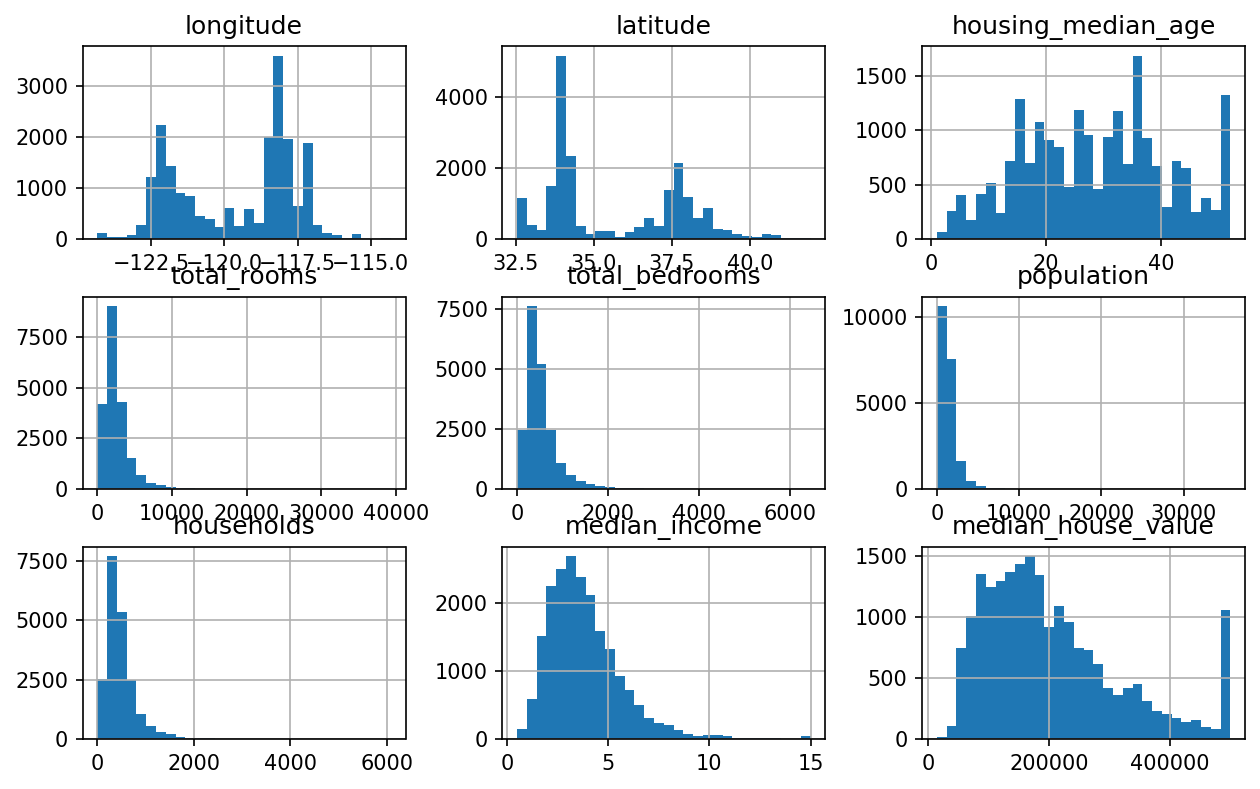

In [78]:
housing.hist(bins=30)

 Verificamos que temos várias variáveis com uma cauda longa, então
vamos aplicar log a elas para suavizar, e depois normalizar. 
Tambem vamos imputar nos valores nulos de total_bedrooms

In [79]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

log_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    FunctionTransformer(np.log, feature_names_out='one-to-one'),
    StandardScaler()
)

num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

transformation = ColumnTransformer([
    ('log', log_pipeline, ['total_bedrooms', 'total_rooms', 'population',
                           'households', 'median_income']),

    ], remainder=num_pipeline
)

housing_selected = housing.drop(['longitude', 'latitude', 'ocean_proximity'], axis=1)

#### Dividindo entre treino e teste

In [80]:
splitter = ShuffleSplit(n_splits=1, test_size=.20, random_state=0)
strat_splits = []
for train_index, test_index in splitter.split(housing_selected):
    train_set_n = housing_selected.iloc[train_index]
    test_set_n = housing_selected.iloc[test_index]
    strat_splits.append([train_set_n, test_set_n])


train_set = strat_splits[0][0]
test_set = strat_splits[0][1]

print('Total de exemplos')
print(f'Treino: {len(train_set)}')
print(f'Teste: {len(test_set)}')

X_train_set = train_set.drop(columns=['median_house_value'])
y_train_set = train_set['median_house_value'].copy()

X_test_set = test_set.drop(columns=['median_house_value'])
y_test_set = test_set['median_house_value'].copy()

Total de exemplos
Treino: 16512
Teste: 4128


#### Testando

In [81]:
lin_reg = make_pipeline(transformation, LinearRegression())
lin_reg.fit(X_train_set, y_train_set)

,steps,"[('columntransformer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('log', ...)]"
,remainder,Pipeline(step...ardScaler())])
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [84]:
train_predictions = lin_reg.predict(X_train_set)
train_mae = mean_absolute_error(train_predictions, y_train_set)
print(f'O erro medio absoluto no conjunto de treino foi de {round(train_mae, 2)}')

O erro medio absoluto no conjunto de treino foi de 59599.4


In [86]:
test_predictions = lin_reg.predict(X_test_set)
test_mae = mean_absolute_error(test_predictions, y_test_set)
print(f'O erro medio absoluto no conjunto de teste foi de {round(test_mae, 2)}')

O erro medio absoluto no conjunto de teste foi de 58730.19


Ao utilizarmos mais variaveis, imputarmos valores nulos com a mediana e aplicarmos
transformacoes, reduzimos o erro medio absoluto.